In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('../data/newport_raw.csv', dtype=str)
df_melted = pd.read_csv('../data/newport_melted.csv')
df_melted

,loc_id,t,visits
0,1299152,0.000000,0.285714
1,1299152,0.041667,0.142857
2,1299152,0.083333,0.000000
3,1299152,0.125000,0.000000
4,1299152,0.166667,0.142857
...,...,...,...
110467,5000416,0.791667,0.793651
110468,5000416,0.833333,0.000000
110469,5000416,0.875000,0.000000
110470,5000416,0.916667,0.793651


In [9]:
df.columns = df.columns.str.lower()

In [6]:
visits_cols = [
  col for col in df.columns 
  if re.match(r'^visits_h\d+$', col)
]

df[visits_cols] = df[visits_cols].apply(
  pd.to_numeric, 
  errors='coerce'
)

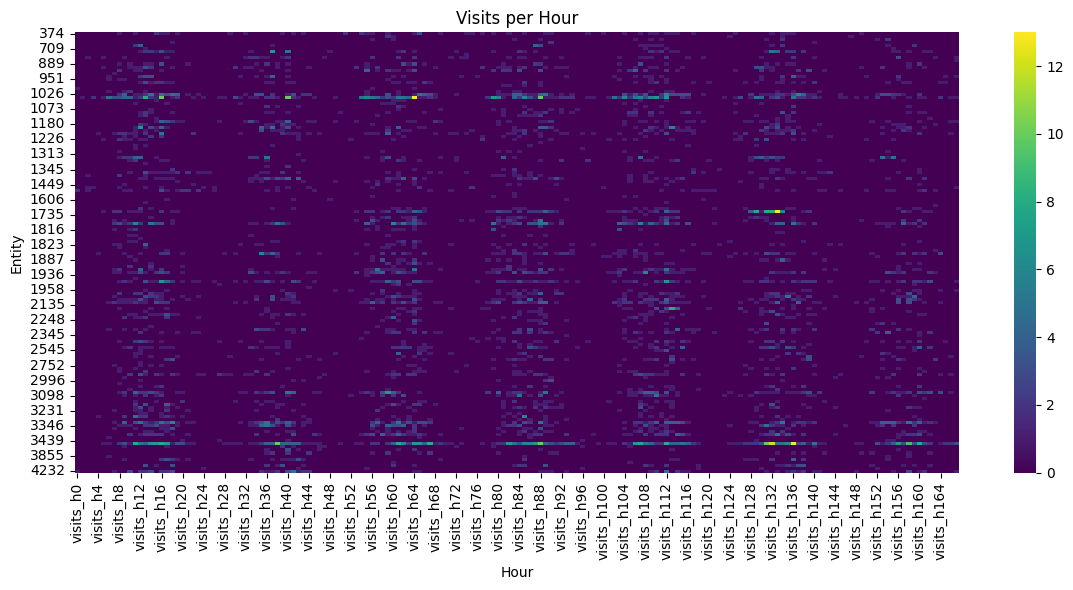

In [7]:
# Extract just the nonmissing visits data
visits_data = df[visits_cols].astype(float).dropna() 

# Heatmap of raw data
plt.figure(figsize=(12, 6))
sns.heatmap(visits_data, cmap='viridis', cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour")
plt.tight_layout()
plt.show()


In [10]:
tr = df.dropna(subset=visits_cols)    #training set

tr = tr.melt(
  id_vars=['prim_occ', 'sqmeters'], 
  value_vars=visits_cols, 
  var_name='hour_of_week', 
  value_name='visits'
)
tr['hour_of_week'] = tr['hour_of_week'].str.extract(r'(\d+)').astype(int)
tr['sqmeters'] = pd.to_numeric(tr['sqmeters'], errors='coerce')
tr['hour'] = tr['hour_of_week'] % 24

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
tr['day'] = tr['hour_of_week'] // 24
tr['day'] = pd.Categorical(
    tr['day'].map(lambda d: days[d]),
    categories=days,
    ordered=True
)
tr['hour_scaled'] = tr['hour'] / 24
tr['sqmeters_scaled'] = tr['sqmeters'] / tr['sqmeters'].max()

tr['sq_q'] = pd.qcut(tr['sqmeters_scaled'], 4, labels=False)

tr['x_day'] = tr['day'].cat.codes
tr['x_prim_occ'] = tr['prim_occ'].astype('category').cat.codes



In [ ]:
x_hour = torch.tensor(tr['hour_scaled'].values, dtype=torch.float32).unsqueeze(1)
x_area = torch.tensor(tr['sqmeters_scaled'].values, dtype=torch.float32).unsqueeze(1)
x_day = torch.tensor(tr['x_day'].values, dtype=torch.long)
x_type = torch.tensor(tr['x_prim_occ'].values, dtype=torch.long)

y = torch.tensor(tr['visits'].values, dtype=torch.float32).unsqueeze(1)

x_hour = x_hour.to(device)
x_area = x_area.to(device)
x_day  = x_day.to(device)
x_type = x_type.to(device)
y      = y.to(device)

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        
        input_size = 1 + 1 + 4 + 5
        hidden_size = 128
        output_size = 1
        
        self.day_emb = nn.Embedding(7, 4)
        self.type_emb = nn.Embedding(13, 5)
        
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Softplus()  
        )

    def forward(self, x_hour, x_area, x_day, x_type):
        x_day_emb = self.day_emb(x_day) 
        x_type_emb = self.type_emb(x_type)
        x = torch.cat([x_hour, x_area, x_day_emb, x_type_emb], dim=1)
        return self.net(x)

In [11]:
loss_fn = nn.PoissonNLLLoss(log_input=False)

In [12]:
model = Net().to(device)

In [13]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [16]:
num_epochs = 1000
for epoch in range(num_epochs):
    model.train()
    
    optimizer.zero_grad()
    loss = loss_fn(model(x_hour, x_area, x_day, x_type), y)
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}")


Epoch 0: loss = 0.8024
Epoch 50: loss = 0.5004
Epoch 100: loss = 0.4594
Epoch 150: loss = 0.4209
Epoch 200: loss = 0.3771
Epoch 250: loss = 0.3689
Epoch 300: loss = 0.3660
Epoch 350: loss = 0.3641
Epoch 400: loss = 0.3621
Epoch 450: loss = 0.3608
Epoch 500: loss = 0.3593
Epoch 550: loss = 0.3586
Epoch 600: loss = 0.3573
Epoch 650: loss = 0.3558
Epoch 700: loss = 0.3550
Epoch 750: loss = 0.3542
Epoch 800: loss = 0.3524
Epoch 850: loss = 0.3522
Epoch 900: loss = 0.3506
Epoch 950: loss = 0.3493


In [16]:
model.eval()
with torch.no_grad():
    pred = (model(x_hour, x_area, x_day, x_type)
            .detach()
            .cpu()
            .squeeze()
            .numpy())
    obs = y.detach().cpu().squeeze().numpy()

df_pred = pd.DataFrame({
    'type':    tr['prim_occ'],
    'day':     tr['day'],        
    'hour':    tr['hour'],           
    'sq_q':    tr['sq_q'],
    'pred':    pred,
    'obs':     obs
})

df_grp = (
    df_pred
    .groupby(['type', 'day','hour'], observed=True)[['pred','obs']]
    .mean()
    .reset_index()
)



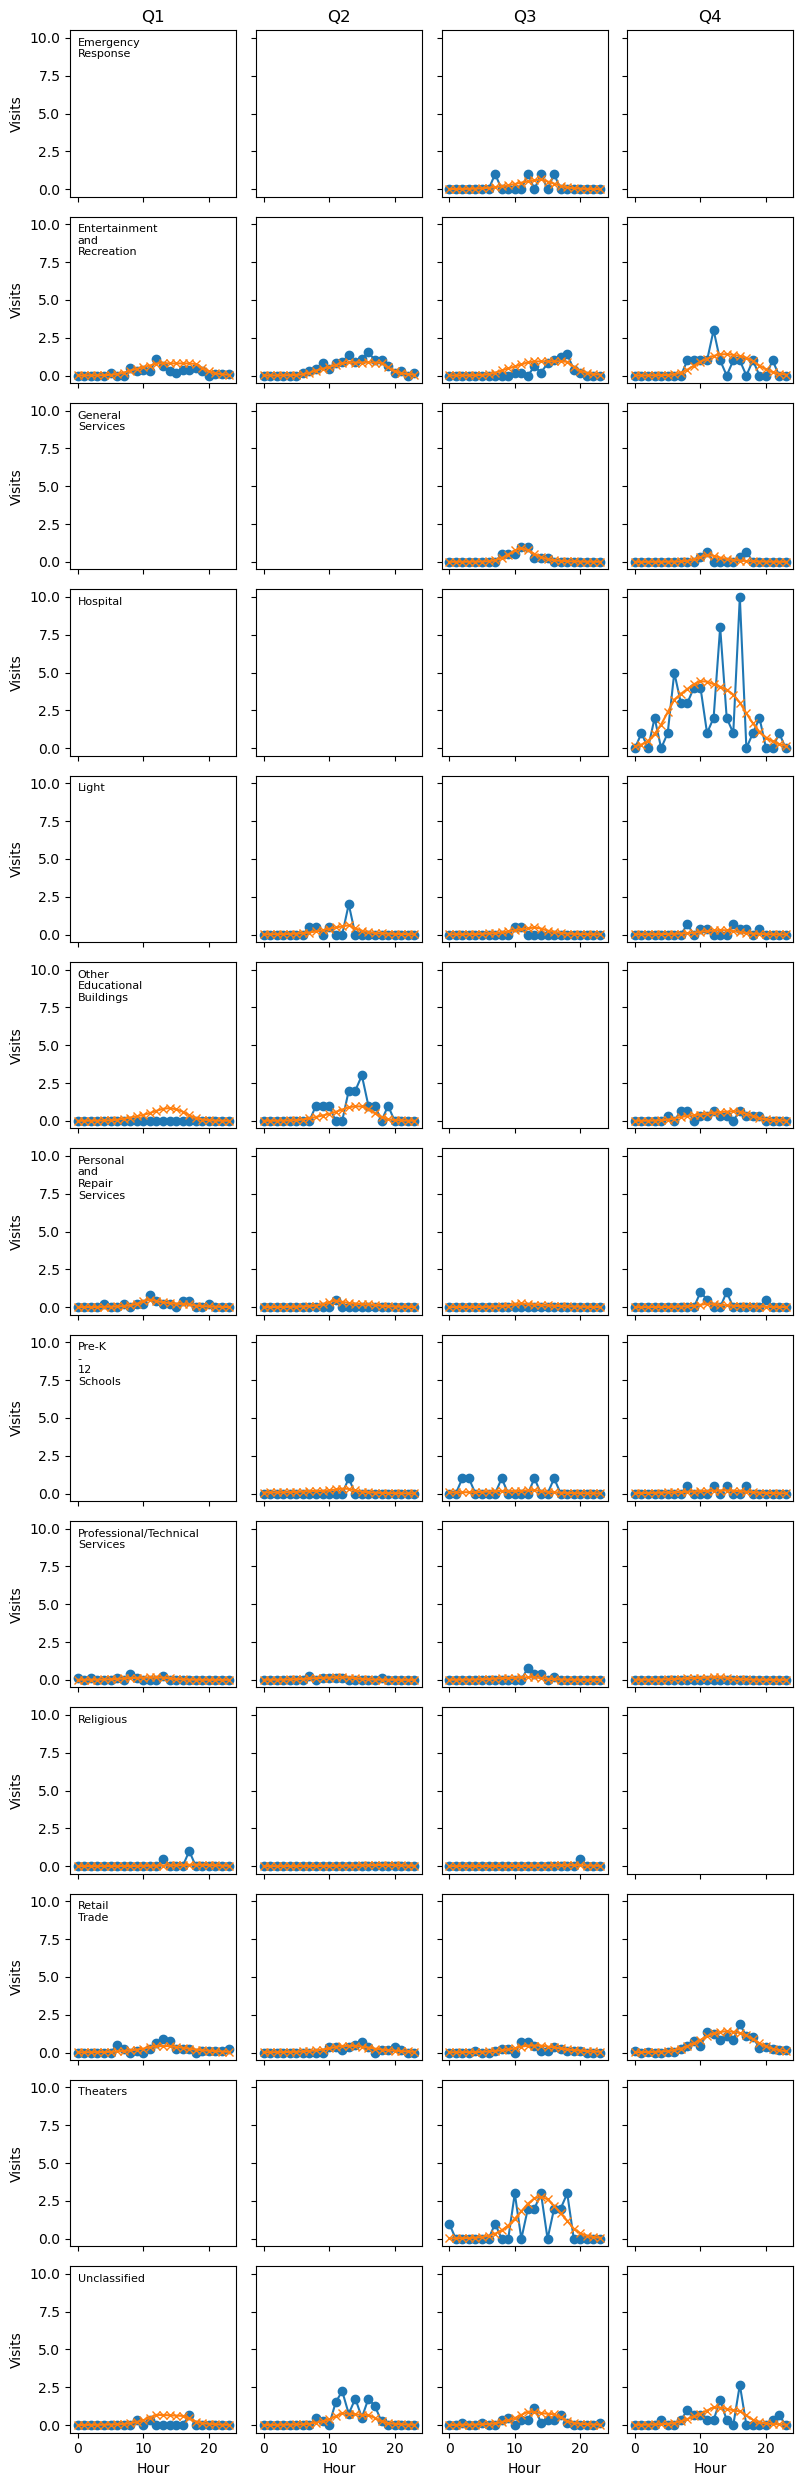

In [17]:
# Parameters
day = 'Mon'
quartiles = range(4)
types = sorted(df_pred['type'].dropna().unique())
n_types = len(types)

# Set up plot grid
fig, axes = plt.subplots(n_types, 4, figsize=(8, 2 * n_types), sharex=True, sharey=True)
axes = np.atleast_2d(axes)  # ensures 2D shape even if n_types == 1

for row, btype in enumerate(types):
    for col, q in enumerate(quartiles):
        ax = axes[row, col]
        mask = (
            (df_pred['type'] == btype) &
            (df_pred['day'] == day) &
            (df_pred['sq_q'] == q)
        )
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby('hour', observed=True)[['obs', 'pred']].mean()
            ax.plot(grp.index, grp['obs'],  marker='o', label='Observed')
            ax.plot(grp.index, grp['pred'], marker='x', label='Predicted')

        if col == 0:
            ax.set_ylabel("Visits")
        if row == n_types - 1:
            ax.set_xlabel("Hour")
        if row == 0:
            ax.set_title(f"Q{q+1}")

    # Add building type label inside leftmost subplot
    left_ax = axes[row, 0]
    label = '\n'.join(btype.split())
    left_ax.text(
        x=0, y=10, s=label,
        ha='left', va='top',
        fontsize=8, color='black',
        transform=left_ax.transData
    )

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


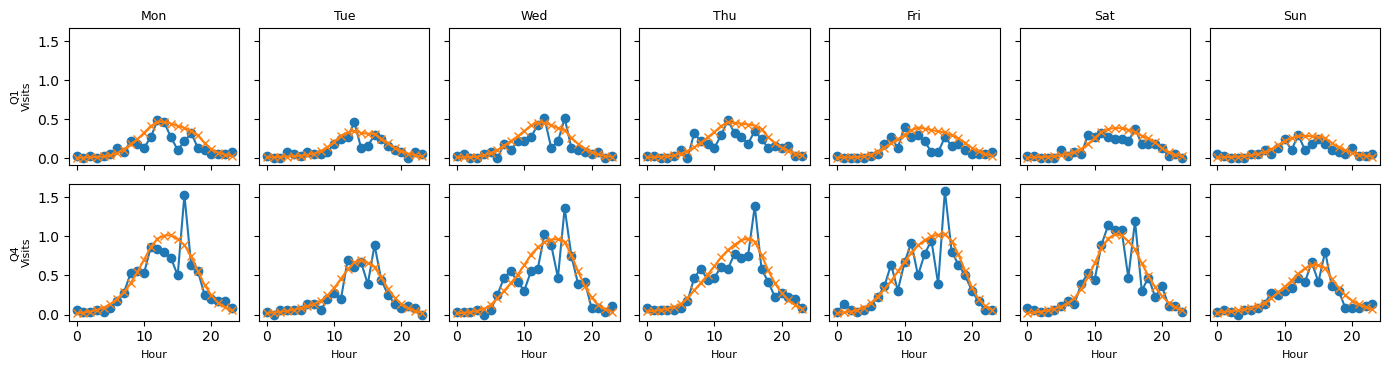

In [19]:
# Parameters
quartiles = [0, 3]  # Q1 and Q4
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Set up plot grid: 2 rows (Q1 and Q4), 7 columns (days)
fig, axes = plt.subplots(2, 7, figsize=(14, 4), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for row, q in enumerate(quartiles):
    for col, day in enumerate(days):
        ax = axes[row, col]
        mask = (
            (df_pred['day'] == day) &
            (df_pred['sq_q'] == q)
        )
        sub = df_pred[mask]

        if not sub.empty:
            grp = sub.groupby('hour', observed=True)[['obs', 'pred']].mean()
            ax.plot(grp.index, grp['obs'], marker='o', label='Observed')
            ax.plot(grp.index, grp['pred'], marker='x', label='Predicted')

        if col == 0:
            ax.set_ylabel(f"Q{q+1}\nVisits", fontsize=8)
        if row == 1:
            ax.set_xlabel("Hour", fontsize=8)
        if row == 0:
            ax.set_title(day, fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [20]:
# Save the model weights
torch.save(model.state_dict(), 'model_weights.pth')

In [6]:
# Demo of loading model
# note need the Net() class definition to load the model
model_loaded = Net()
model_loaded.load_state_dict(torch.load('model_weights.pth', map_location='cpu'))
model_loaded.eval() 

with torch.no_grad():
    sample_preds = model_loaded(x_hour, x_area, x_day, x_type)

print("Sample predictions:", sample_preds[:5])

NameError: name 'Net' is not defined